In [11]:
import sys
from datetime import datetime
import tracemalloc
import pdb
import os
import ipynbname
import gc
import glob
import ast
import traceback
import time
import shutil

#math
import math
import re
import itertools
import ast
import csv
import numpy as np
import pandas as pd
import seaborn as sns
import collections
from collections import Counter, defaultdict

#JSON output
import json
import IPython
from IPython.display import display, JSON

#graph
import networkx as nx
from graphviz import Digraph
from IPython.display import display, JSON
from scipy import stats

#plots
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.image as mpimg
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

#packages for Persistence Topology analysis
import plotly.tools as tls
import plotly.graph_objects as go
import plotly.io as pio
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from gudhi import RipsComplex, SimplexTree
from gudhi.wasserstein import wasserstein_distance
import gudhi

print('sys verson = ' + sys.version)
print('IPython verson = ' + IPython.__version__)

%matplotlib inline
my_client = fbl.get_client()

2026-05-28 03:24:57.608570: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-28 03:25:01.238636: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib:/usr/local/cuda/lib64:/usr/lib:/usr/lib/x86_64-linux-gnu:/usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-05-28 03:25:01.239054: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib:/usr/local/cuda/lib64:/usr/lib:/usr/lib/x86_64-linux-gnu:/usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-05-28 03:25:01.239071: W tensorflow/compiler/tf2tensorr

sys verson = 3.9.16 | packaged by conda-forge | (main, Feb  1 2023, 21:39:03) 
[GCC 11.3.0]
IPython verson = 8.14.0


In [14]:
data = my_client.executeNLPquery('clear')

[FBL NLP 2026-04-22 23:55:56,021] NLP successfully parsed query.


In [12]:
#Neurmorphology and Simulation
import neuroarch.na as na
dbDataset = na.NeuroArch("hemibrain",port=2424) #create connection to flywire

In [13]:
import neuroarch.version
print(neuroarch.version.__version__)

0.4.3


In [13]:
#turn on breakpoints?
%pdb on

Automatic pdb calling has been turned ON


# Github

In [11]:
!git init
!git remote add origin https://github.com/sgarnell/archive

Reinitialized existing Git repository in /home/ffbo/ffbo/.git/
fatal: remote origin already exists.


In [12]:
!git remote -v

origin	https://github.com/sgarnell/archive.git (fetch)
origin	https://github.com/sgarnell/archive.git (push)


In [14]:
# Stage the notebook file
!git add 'ephaptic_coupling_v1.ipynb'

# Commit the changes
!git commit -m "Auto commit from Jupyter for {notebook_name}"

# Push to GitHub
!git push origin fbl2-main

[fbl2-main 2313c59] Auto commit from Jupyter for {notebook_name}
 1 file changed, 98 insertions(+), 215 deletions(-)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 16 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1.53 KiB | 174.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0)
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/sgarnell/archive.git
   22cebb5..2313c59  fbl2-main -> fbl2-main


# Initialize

# Optional

In [13]:
# Query to retrieve sample records from the Neuropil class
query = "SELECT * FROM MetaData LIMIT 100"  # Adjust the limit as needed
metadata_records = dbDataset.sql_query(query)


if len(metadata_records) == 0:
    print("No records found in the 'metaData' class.")
else:
    print("Sample records in 'metaData' class:")
    for record in metadata_records:
        # Print the ID and the properties of each record
        print(f"version: {record.version}, registryname: {  record.props }")
        #print(str(record.))
        # Synonyms: {record.get_props['synonyms']}


Sample records in 'metaData' class:
version: 2.0.1, registryname: {'created_by': {'min_NeuroArch_version_supported': '0.4.1', 'created_date': '2022-06-18T02:10:08.724498', 'NeuroArch_version': '0.4.0', 'OrientDB_version': '3.1.17'}, 'maintainer': {'name': 'Yiyin Zhou', 'email': 'yiyin@ee.columbia.edu'}, 'version': '2.0.1'}


In [ ]:
# Query to retrieve all class types in the OrientDB database
query = "SELECT name FROM (SELECT expand(classes) FROM metadata:schema)"
class_types = dbDataset.sql_query(query)

if len(class_types) == 0:
    print("No class types found in the database.")
else:
    # Store class names in a list
    class_names = [class_type.name for class_type in class_types]

    # Sort the list alphabetically
    sorted_class_names = sorted(class_names)

    # Print the sorted list
    for class_name in sorted_class_names:
        print(class_name)


In [15]:
####Total Schema #######
def get_class_metadata(className, client, visited=None):

    tempMetaData = {}
    # Query to retrieve sample records from the Neuropil class
    query = f"SELECT * FROM {className} LIMIT 1"  # Adjust the limit as needed
    class_records = client.sql_query(query)
    for record in class_records:
        tempMetaData[className] = str(record._props)
    #print(f"ID: {record._id}, Name: {record._props['name']}, Synonyms: {record._props['synonyms']}")
    
    if not tempMetaData:
        return {}

    return tempMetaData

def get_full_metadata(client):
    
    #clear dicts
    metadata_dict = {}
    query = "SELECT name FROM (SELECT expand(classes) FROM metadata:schema)"
    class_types = client.sql_query(query)
    #list of names
    class_names = [class_type.name for class_type in class_types]
    for className in class_names:
        classProps = get_class_metadata(className, client)
        metadata_dict[className] = classProps
    return metadata_dict #return dict

# Connect to the database

# Get metadata and save to JSON
metadata_dict = get_full_metadata(dbDataset)

with open("metadata_tree.json", "w") as f:
    json.dump(metadata_dict, f, indent=4)

print("Metadata saved to metadata_tree.json")


Metadata saved to metadata_tree.json


In [16]:


# Query to retrieve sample records from the Neuropil class
query = "SELECT * FROM Neuropil LIMIT 100"  # Adjust the limit as needed
neuropil_records = dbDataset.sql_query(query)

if len(neuropil_records) == 0:
    print("No records found in the 'Neuropil' class.")
else:
    print("Sample records in 'Neuropil' class:")
    for record in neuropil_records:
        # Print the ID and the properties of each record
        print(f"ID: {record._id}, Name: {record._props['name']}, Synonyms: {record._props['synonyms']}")


Sample records in 'Neuropil' class:
ID: #408:0, Name: PLP(R), Synonyms: None
ID: #419:0, Name: ATL(L), Synonyms: None
ID: #432:0, Name: SCL(R), Synonyms: None
ID: #397:1, Name: AB(R), Synonyms: None
ID: #394:1, Name: SPS(R), Synonyms: None
ID: #406:0, Name: LAL(L), Synonyms: None
ID: #425:0, Name: LOP(R), Synonyms: None
ID: #404:0, Name: BU(L), Synonyms: None
ID: #397:0, Name: AL(R), Synonyms: None
ID: #426:0, Name: FB, Synonyms: None
ID: #415:0, Name: CRE(R), Synonyms: None
ID: #413:0, Name: SMP(R), Synonyms: None
ID: #423:0, Name: PRW, Synonyms: None
ID: #438:0, Name: EPA(R), Synonyms: None
ID: #407:0, Name: AOTU(R), Synonyms: None
ID: #401:0, Name: AME(R), Synonyms: None
ID: #437:0, Name: VES(L), Synonyms: None
ID: #394:0, Name: MB(R), Synonyms: None
ID: #431:0, Name: PVLP(R), Synonyms: None
ID: #439:0, Name: EPA(L), Synonyms: None
ID: #418:0, Name: ATL(R), Synonyms: None
ID: #441:0, Name: GOR(L), Synonyms: None
ID: #398:1, Name: AB(L), Synonyms: None
ID: #417:0, Name: IB, Synonyms:

# Get Neurons within the Neuropil of interest.

## This cell provides:
 - a clean list of all FB neurons
- a reproducible starting point
- a foundation for filtering by layer

In [17]:

# --- Step 1: Select the FB neuropil ---
FB = dbDataset.sql_query('SELECT FROM Neuropil WHERE name = "FB"')

# --- Step 2: Get all neurons that arborize in the FB ---
fb_neurons = FB.gen_traversal_in(['ArborizesIn', 'Neuron'], min_depth=1)

# --- Step 3: Extract unique cell types ---
celltypes = sorted({n.name for n in fb_neurons.node_objs})
print(f"Found {len(celltypes)} FB-innervating cell types")

# --- Step 4: Preview a few ---
for n in itertools.islice(fb_neurons.node_objs, 50):
    print(n.props['name'])


Found 299 FB-innervating cell types
FS1A
FB6J
FC1F
vDeltaL
PEG
PFNp_b
VM5v_adPN
PFNd
vDeltaB
FC1D
FB5A
FC1C
hDeltaL
FB1D
PFGs
FB6I
unknown
unknown
vDeltaC
PFNp_b
PFNp_b
unknown
FS1A
FB6X
FB3C
FC1B
FB6U
vDeltaM
FC1C
FS3
hDeltaI
SA2_a
FB5X
PFNv
vDeltaL
FB4E
FS4C
PFNa
vDeltaA_a
PFNp_d
FC2B
FB4R
FC2B
CL209
FS4A
vDeltaA_b
FS1B
FB5V
PFNp_a
vDeltaE


In [22]:
#Supporting routine to locate post and pre synapses

def locate_psd(q, prob = 0.0, cell_type = False, travIn = True):
    
    if travIn == True:
        prepost_synapse_morph  = q.gen_traversal_in(
                                ['SendsTo', 'Synapse'],
                                min_depth = 1).gen_traversal_out(
                                ['HasData', 'MorphologyData'],
                                min_depth = 1)
    else:
         prepost_synapse_morph  = q.gen_traversal_out(
                                ['SendsTo', 'Synapse'],
                                ['HasData', 'MorphologyData'],
                                min_depth = 2)
    
    x = []
    y = []
    z = []
    names = []
    neuron_ind = []
    for i, n in enumerate(prepost_synapse_morph):
        
        # pre = presynaptic_neuron_uname(n.uname)
        if travIn == True:
            synName = n.uname.split('--',1)[0]
        else:
            synName = n.uname.split('--',1)[1]
            
        names.append(synName)
        n_syn = len(n.x)//2
        try:
            if len(n.confidence):
                conf = [a >= prob and b >= prob for a, b in zip(n.confidence[:n_syn], n.confidence[n_syn:])]
            elif len(n.confidence) == n_syn:
                conf = [a >= prob for a in n.confidence]
            else:
                raise ValueError()
            x.extend([v for v, c in zip(n.x[n_syn:], conf) if c])
            y.extend([v for v, c in zip(n.y[n_syn:], conf) if c])
            z.extend([v for v, c in zip(n.z[n_syn:], conf) if c])
            neuron_ind.extend([i] * sum(conf))
        except:
            x.extend(n.x[n_syn:])
            y.extend(n.y[n_syn:])
            z.extend(n.z[n_syn:])
            neuron_ind.extend([i] * n_syn)
    psd = {(x[i], y[i], z[i]): names[neuron_ind[i]] for i in range(len(x))}
    return psd

In [19]:
print(type(fb_neurons))
print(type(fb_neurons.node_objs[0]))
n = fb_neurons.node_objs[0]
print("---Neuron Data---")
print("Neuron object:", n)
print("Properties:", n.props)
print("Attributes:", dir(n))
print("---Synapse Data---")
# Pick any neuron that arborizes in the FB

n = fb_neurons.node_objs[0]
q = fb_neurons.from_objs(dbDataset.graph, [n])

psds = locate_psd(q, travIn=True)

# Now inspect one morphology object directly
syn = q.gen_traversal_in(['SendsTo', 'Synapse'], min_depth=1)
syn_morph = syn.gen_traversal_out(['HasData', 'MorphologyData'], min_depth=1)

print(syn_morph.node_objs[0]._props)






<class 'neuroarch.query.QueryWrapper'>
<class 'neuroarch.models.Neuron'>
---Neuron Data---
Neuron object: <neuroarch.models.Neuron object at 0x7fa8c85889a0>
Properties: {'info': {'Hemibrain Trace Status': 'Roughly traced'}, 'label': None, 'locality': None, 'name': 'FS1A', 'referenceId': '1039085109', 'synonyms': None, 'uname': 'FS1A(FQ9)_C6_R_1'}
Attributes: ['Abstract', 'Broker', 'PropertyLookup', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_graph', '_id', '_props', 'both', 'bothE', 'context', 'decl_root', 'decl_type', 'element_plural', 'element_type', 'from_graph', 'get_props', 'gremlin', 'gremlin_raw', 'inE', 'in_', 'info', 'label', 'load', 'locality', 'name', 'objects', 'out

In [21]:
def get_fb_layer_neurons(layer_number):
    """
    Returns all neurons whose celltype name begins with FB{layer_number}.
    Example: layer_number=1 → FB1A, FB1B, FB1G, etc.
    """
    prefix = f"FB{layer_number}"
    q = dbDataset.sql_query(
        f'SELECT FROM Neuron WHERE name LIKE "{prefix}%"'
    )
    return q.node_objs

fb1_neurons = get_fb_layer_neurons(1)
for n in fb1_neurons:
    print(f"uname: {n.props['uname']} - referenceID: {n.props['referenceId']}")



uname: FB1E_a_R_1 - referenceID: 1224254199
uname: FB1J_L_1 - referenceID: 885939922
uname: FB1C(NO1/NO3)_L_2 - referenceID: 1379087619
uname: FB1D_R_2 - referenceID: 294791509
uname: FB1E_a_R_2 - referenceID: 1293468282
uname: FB1B_L_2 - referenceID: 5813009284
uname: FB1E_b_R_1 - referenceID: 295136965
uname: FB1D_R_1 - referenceID: 265120597
uname: FB1J_R_1 - referenceID: 885598938
uname: FB1B_L_1 - referenceID: 1168387674
uname: FB1D_L_1 - referenceID: 5813002500
uname: FB1C(NO1/NO3)_L_1 - referenceID: 1348057533
uname: FB1F_R_1 - referenceID: 5813010148
uname: FB1C(NO1/NO3)_R_2 - referenceID: 5813055913
uname: FB1B_R_1 - referenceID: 296514350
uname: FB1A_L_2 - referenceID: 422881784
uname: FB1F_L_1 - referenceID: 1254947903
uname: FB1E_a_L_2 - referenceID: 731192952
uname: FB1H(NO2/3)_L_1 - referenceID: 519046655
uname: FB1A_L_1 - referenceID: 1442176747
uname: FB1B_R_2 - referenceID: 358251878
uname: FB1D_L_2 - referenceID: 5813002689
uname: FB1E_a_L_1 - referenceID: 421184151
u

In [23]:
#Get synapses and point clouds for each layer

def extract_synapse_points(morph_obj, prob=0.0):
    """
    Extracts (x,y,z) synapse coordinates from a MorphologyData object.
    Applies confidence filtering if available.
    Returns a list of (x,y,z) tuples.
    """
    points = []
    n_syn = len(morph_obj.x) // 2

    # Confidence filtering
    if hasattr(morph_obj, "confidence") and len(morph_obj.confidence) > 0:
        if len(morph_obj.confidence) == 2 * n_syn:
            conf = [a >= prob and b >= prob
                    for a, b in zip(morph_obj.confidence[:n_syn],
                                    morph_obj.confidence[n_syn:])]
        else:
            conf = [c >= prob for c in morph_obj.confidence]
    else:
        conf = [True] * n_syn

    # Extract post-synaptic coordinates
    xs = morph_obj.x[n_syn:]
    ys = morph_obj.y[n_syn:]
    zs = morph_obj.z[n_syn:]

    for x, y, z, c in zip(xs, ys, zs, conf):
        if c:
            points.append((x, y, z))

    return points



def get_layer_pointcloud(layer_number, incoming=True, max_neurons=None, prob=0.0, gc_every=5):
    """
    Extracts a full point cloud of synapses for all neurons in FB layer N.
    Also returns a dict counting synapses per incoming neuron cell type.
    Performs aggressive memory cleanup after each neuron.
    """

    prefix = f"FB{layer_number}"
    q = dbDataset.sql_query(f'SELECT FROM Neuron WHERE name LIKE "{prefix}%"')
    neurons = q.node_objs

    if max_neurons is not None:
        neurons = neurons[:max_neurons]

    all_points = []
    synapse_counts = defaultdict(int)

    print(f"\n=== Processing FB Layer {layer_number} ===")
    print(f"Found {len(neurons)} neurons matching prefix {prefix}\n")

    # --- Progress printing ---
    max_print = 5  # print first 5 neurons in full

    for idx, neuron in enumerate(neurons, start=1):

        if idx <= max_print:
            # Detailed print for first few neurons
            print(f"[{idx}/{len(neurons)}] Neuron: {neuron.props['uname']}")
        else:
            # Dot every 10 neurons
            if idx % 10 == 0:
                print("\033[32m.\033[0m", end="", flush=True)

            # Block marker every 100 neurons
            if idx % 100 == 0:
                print(" | ", end="", flush=True)

            # Newline every 1000 neurons
            if idx % 1000 == 0:
                print(f"  ({idx})", flush=True)

        # Wrap neuron in traversal object
        nq = q.from_objs(dbDataset.graph, [neuron])

        # Incoming or outgoing synapses
        if incoming:
            syn = nq.gen_traversal_in(['SendsTo', 'Synapse'], min_depth=1)
        else:
            syn = nq.gen_traversal_out(['SendsTo', 'Synapse'], min_depth=1)

        syn_morph = syn.gen_traversal_out(['HasData', 'MorphologyData'], min_depth=1)

        # Extract coordinates + count per presynaptic cell type
        for morph_obj in syn_morph.node_objs:

            pts = extract_synapse_points(morph_obj, prob=prob)
            all_points.extend(pts)

            try:
                pre_name = morph_obj.uname.split("--")[0]
            except:
                pre_name = "UNKNOWN"

            synapse_counts[pre_name] += len(pts)

        # --- MEMORY CLEANUP SECTION ---
        del syn_morph
        del syn
        del nq

        # Optional: free memory every N neurons
        if (idx + 1) % gc_every == 0:
            gc.collect()

    # Sort counts
    sorted_counts = dict(sorted(synapse_counts.items(), key=lambda x: x[1], reverse=True))

    print("\n=== Synapse Counts by Incoming Neuron Type ===")
    for name, count in list(sorted_counts.items())[:20]:
        print(f"{name:30s}  {count}")

    print(f"\nTotal synapses in layer {layer_number}: {len(all_points)}\n")

    # Final cleanup
    gc.collect()

    return all_points, sorted_counts



In [24]:

fb5_points, fb5_sources = get_layer_pointcloud(5, incoming=True)
print(f"FB5 synapse count: {len(fb5_points)}")


=== Processing FB Layer 5 ===
Found 112 neurons matching prefix FB5

[1/112] Neuron: FB5G_L_1
[2/112] Neuron: FB5X_R_2
[3/112] Neuron: FB5J_L_1
[4/112] Neuron: FB5V_L_5
[5/112] Neuron: FB5P_R_2
.......... | .
=== Synapse Counts by Incoming Neuron Type ===
FB5H_R_1                        1170
FB5H_L_1                        1147
oviIN_R_1                       885
FB4Y(EB/NO1)_L_2                803
OA-VPM3(NO2/NO3)_R_1            795
FB5L_L_1                        788
oviIN_L_1                       727
FB4Y(EB/NO1)_R_1                711
FB5L_R_1                        703
FB5AB_R_1                       638
hDeltaH_12_C7_1                 633
OA-VPM3(NO2/NO3)_L_1            626
CRE107(SCB016)_L_1              621
FB5AB_L_1                       619
FB5I_R_1                        612
FB4Y(EB/NO1)_L_1                609
FB4Y(EB/NO1)_R_2                586
hDeltaH_14_C8_1                 581
hDeltaH_11_C6_1                 572
FB5I_L_1                        567

Total synapses in la

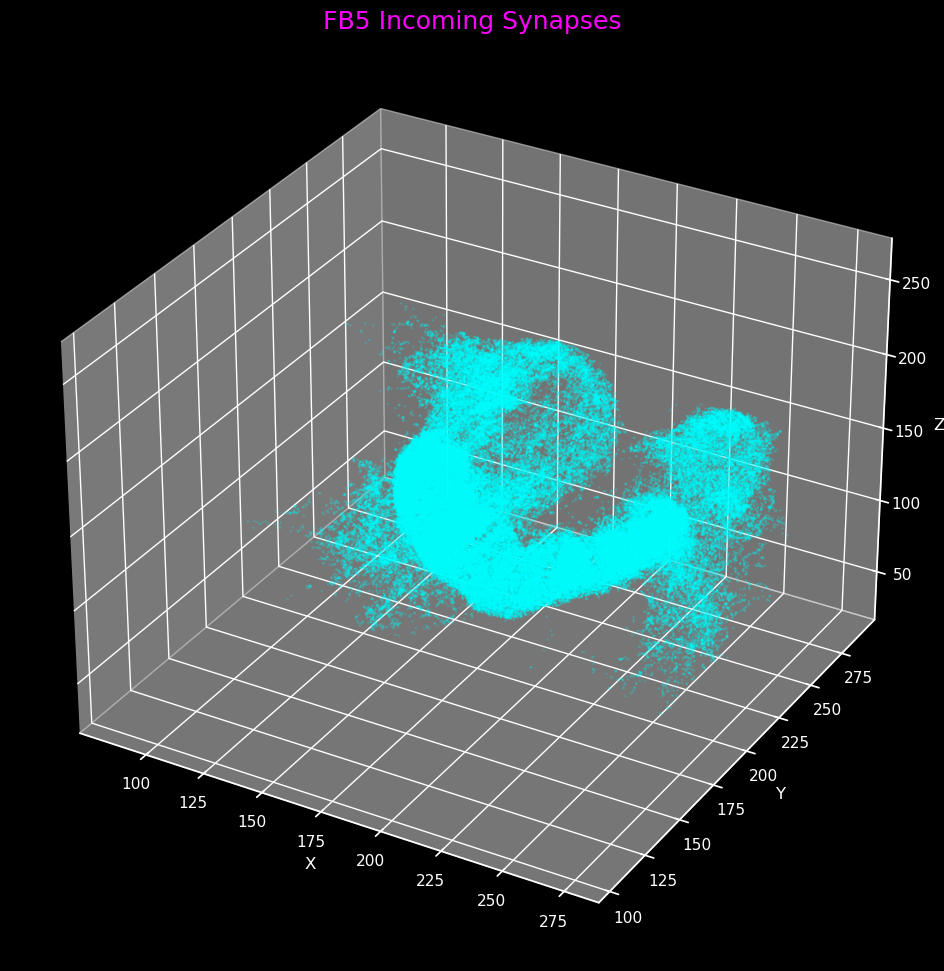

In [25]:
def visualize_layer_pointcloud(points, title="FB Layer", color="cyan", alpha=0.3, s=1):
    """
    Simple, fast 3D scatter for large FB layer point clouds.
    points: list of (x,y,z)
    """

    pts = np.array(points)
    x, y, z = pts[:,0], pts[:,1], pts[:,2]

    fig = plt.figure(figsize=(12,12))
    ax = fig.add_subplot(111, projection='3d')

    ax.set_facecolor("black")
    fig.patch.set_facecolor("black")

    ax.scatter(x, y, z, s=s, c=color, alpha=alpha)

    ax.set_xlabel("X", color="white")
    ax.set_ylabel("Y", color="white")
    ax.set_zlabel("Z", color="white")

    ax.tick_params(colors="white")
    plt.title(title, color="magenta", fontsize=18)

    plt.show()
    
visualize_layer_pointcloud(
    fb5_points,
    title="FB5 Incoming Synapses",
    color="cyan",
    alpha=0.15,
    s=1
)


In [26]:
from IPython.display import clear_output
clear_output(wait=True)


def cleanup_memory():
    plt.close('all')   # close all matplotlib figures
    gc.collect()       # force Python garbage collection

cleanup_memory()

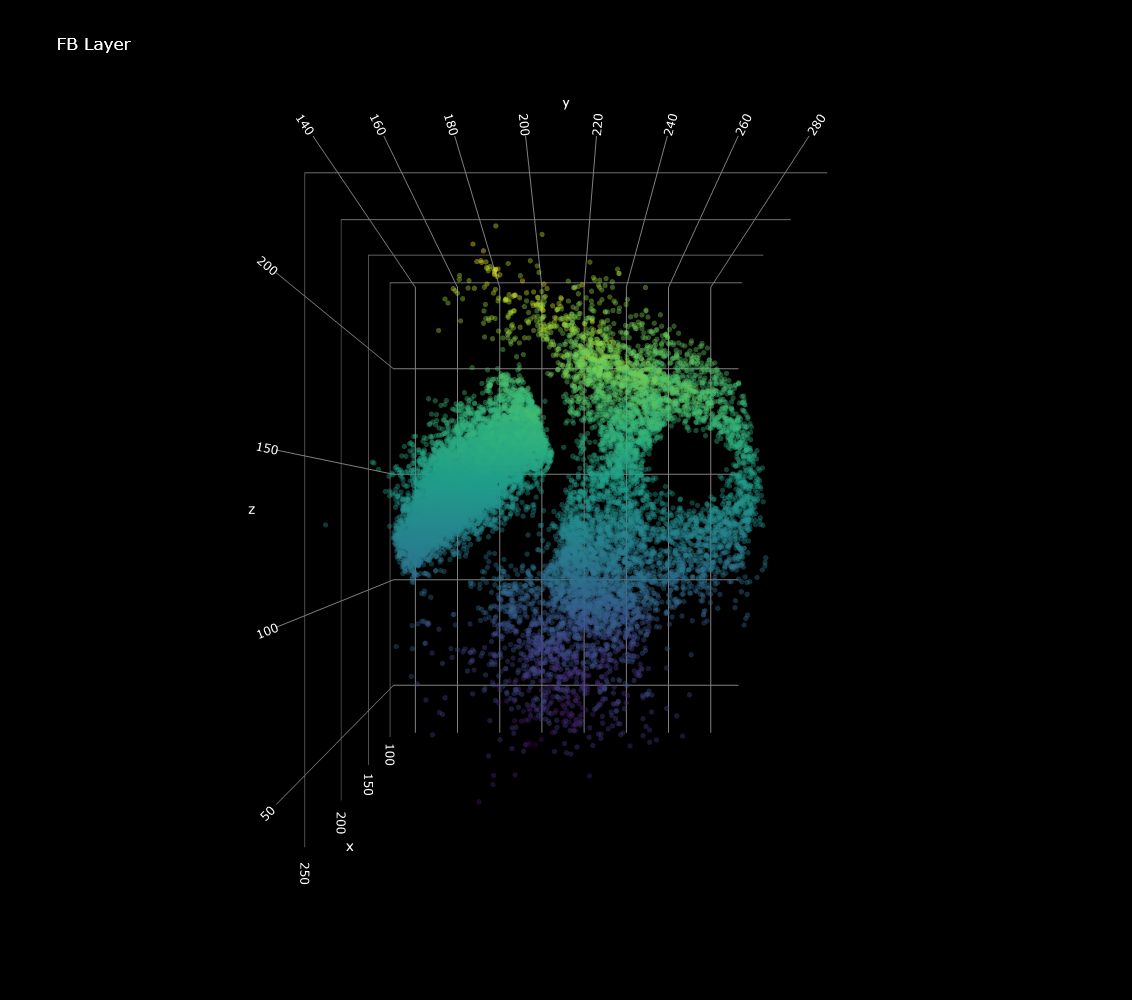

In [27]:




def visualize_layer_plotly(points, title="FB Layer"):
    pts = np.array(points)
    x, y, z = pts[:,0], pts[:,1], pts[:,2]

    fig = go.Figure(data=[go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=3,        # <--- increase point size here
            opacity=0.4,
            color=z,
            colorscale='Viridis'
        )
    )])
    
    anterior_camera = dict(
    eye=dict(x=2, y=0, z=0),   # camera in front of the FB
    up=dict(x=0, y=1, z=1),         # z-axis is up
    center=dict(x=0, y=0, z=0) )


    fig.update_layout(
        scene_camera=anterior_camera,
        title=title,
        height=1000,       # <--- increase vertical height of the viewer
        width=1200,        # <--- optional: increase width too
        scene=dict(
            bgcolor="black",
            xaxis=dict(backgroundcolor="black", gridcolor="gray"),
            yaxis=dict(backgroundcolor="black", gridcolor="gray"),
            zaxis=dict(backgroundcolor="black", gridcolor="gray"),
        ),
        paper_bgcolor="black",
        font=dict(color="white")
    )

    fig.show()

def downsample_points(points, fraction=0.2):
    import random
    k = int(len(points) * fraction)
    return random.sample(points, k)

    
fb5_small = downsample_points(fb5_points, fraction=0.10)
visualize_layer_plotly(fb5_small)



# Data Export

In [68]:
import itertools
import time
from datetime import datetime

def build_global_fb_psd(incoming=True, prob=0.0, max_neurons=None, max_print=5):
    """
    Diagnostic version: prints detailed information while building the global PSD map.
    Includes timestamps and runtime measurement.
    """

    print("\n=== Building Global FB PSD Map ===")
    print(f"Incoming synapses: {incoming}")
    print(f"Confidence threshold: {prob}")
    print(f"Max neurons: {max_neurons}")
    print("----------------------------------")


    # Step 1: Get FB neurons
    FB = dbDataset.sql_query('SELECT FROM Neuropil WHERE name = "FB"')
    fb_neurons = FB.gen_traversal_in(['ArborizesIn', 'Neuron'], min_depth=1)

    total_neurons = len(fb_neurons.node_objs)
    print(f"Total FB-innervating neurons found: {total_neurons}")

    iterator = fb_neurons.node_objs
    if max_neurons is not None:
        iterator = itertools.islice(iterator, max_neurons)

    global_psd = {}
    neuron_counter = 0
    total_synapses = 0

    # Step 2: Loop through neurons
    current_print = 1
    

    for n in iterator:
        neuron_counter += 1

        # Wrap neuron into a traversal
        q = fb_neurons.from_objs(dbDataset.graph, [n])

        # Extract synapses
        psds = locate_psd(q, travIn=incoming, prob=prob)
        syn_count = len(psds)
        

        if current_print <= max_print:
            print(f"Ncounter: {neuron_counter} Name:  {n.uname} Synapse count: {syn_count} ")
            current_print += 1
        # --- Compact progress indicator after that ---
        else:
            # Green dot = synapses found
            # Red dot = zero synapses
            if neuron_counter % 10 == 0:
                dot = "\033[32m.\033[0m" if syn_count > 0 else "\033[31m.\033[0m"
                print(dot, end="", flush=True)

            # Block marker every 100 neurons
            if neuron_counter % 100 == 0:
                print(" | ", end="", flush=True)

            # Newline every 1000 neurons
            if neuron_counter % 1000 == 0:
                print(f"  ({neuron_counter})", flush=True)

        
        # Merge into global map
        # global_psd.update(psds) #deprecated so that we can include referenceId with uname
        # Inject referenceId into each PSD entry
        for coord, uname in psds.items():
            ref_id = None

            # 1) Try Neuron mapping
            if uname in uname_to_refid:
                ref_id = uname_to_refid[uname]

            # 2) If it's a segment_* name, parse bodyId from the suffix
            elif uname.startswith("segment_"):
                try:
                    ref_id = int(uname.split("_", 1)[1])
                except ValueError:
                    ref_id = -1

            # 3) Otherwise, leave as unknown
            else:
                ref_id = -1

            global_psd[coord] = (uname, ref_id)



        total_synapses += syn_count


    # Final newline
    print("\n")
    print("\n=== Global PSD Build Complete ===")
    print(f"Neurons processed: {neuron_counter} Total Synapse: {total_synapses} PSD coords: {len(global_psd)} ")


    return global_psd


In [29]:
# def save_global_psd(global_psd, filename="FB_incoming_all_synapses.npz"):
#     coords = np.array(list(global_psd.keys()), dtype=np.float32)
#     names = np.array(list(global_psd.values()), dtype=object)

#     # Build neuron summary
#     from collections import Counter
#     counter = Counter(names)
#     neuron_names = np.array(list(counter.keys()), dtype=object)
#     counts_per_neuron = np.array(list(counter.values()), dtype=np.int32)

#     # Bounds & centroid
#     xmin, ymin, zmin = coords.min(axis=0)
#     xmax, ymax, zmax = coords.max(axis=0)
#     bounds = np.array([xmin, xmax, ymin, ymax, zmin, zmax], dtype=np.float32)
#     centroid = coords.mean(axis=0).astype(np.float32)

#     # Save using the SAME schema as layer files
#     np.savez(
#         filename,
#         points=coords,
#         pre_names=names,
#         layer=np.full(len(coords), -1, dtype=np.int32),  # -1 = global, no layer
#         bounds=bounds,
#         centroid=centroid,
#         neuron_names=neuron_names,
#         counts_per_neuron=counts_per_neuron,
#         density_grid=None,
#         density_meta=None,
#     )

#     print(f"Saved global PSD file: {filename}")
#     print(f"Total synapses: {len(coords)}")
#     print(f"Unique neuron types: {len(neuron_names)}")




In [69]:
def build_uname_to_refid_map():
    q = dbDataset.sql_query("SELECT uname, referenceId FROM Neuron")
    mapping = {}
    for n in q.node_objs:
        uname = getattr(n, "uname", None)
        refid = getattr(n, "referenceId", None)
        if uname and refid:
            mapping[uname] = int(refid)
    return mapping

uname_to_refid = build_uname_to_refid_map()
print("Total neurons mapped:", len(uname_to_refid))




Total neurons mapped: 25895


In [70]:
#get data for FB_incoming_all_synapses



def save_global_psd(global_psd, filename="FB_incoming_all_synapses.npz"):
    # Coordinates
    coords = np.array(list(global_psd.keys()), dtype=np.float32)

    # Split uname + bodyId
    pairs = list(global_psd.values())
    pre_names = np.array([p[0] for p in pairs], dtype=object)      # uname
    pre_bodyIds = np.array([int(p[1]) for p in pairs], dtype=np.int64)  # bodyId

    # Build neuron summary (based on uname)
    from collections import Counter
    counter = Counter(pre_names)
    neuron_names = np.array(list(counter.keys()), dtype=object)
    counts_per_neuron = np.array(list(counter.values()), dtype=np.int32)

    # Bounds & centroid
    xmin, ymin, zmin = coords.min(axis=0)
    xmax, ymax, zmax = coords.max(axis=0)
    bounds = np.array([xmin, xmax, ymin, ymax, zmin, zmax], dtype=np.float32)
    centroid = coords.mean(axis=0).astype(np.float32)

    # Save using the SAME schema as layer files + new bodyId field
    np.savez(
        filename,
        points=coords,
        pre_names=pre_names,
        pre_bodyIds=pre_bodyIds,     # NEW FIELD
        layer=np.full(len(coords), -1, dtype=np.int32),
        bounds=bounds,
        centroid=centroid,
        neuron_names=neuron_names,
        counts_per_neuron=counts_per_neuron,
        density_grid=None,
        density_meta=None,
    )

    print(f"Saved global PSD file: {filename}")
    print(f"Total synapses: {len(coords)}")
    print(f"Unique neuron types: {len(neuron_names)}")
    



In [71]:
start_time = time.time()
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
global_psd = build_global_fb_psd(incoming=True, max_neurons=None)

# End timing
end_time = time.time()
elapsed = end_time - start_time
print(f"Total time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

save_global_psd(global_psd, filename="FB_incoming_all_synapses.npz")

Start time: 2026-05-28 17:03:12


=== Building Global FB PSD Map ===
Incoming synapses: True
Confidence threshold: 0.0
Max neurons: None
----------------------------------
Total FB-innervating neurons found: 2577
Ncounter: 1 Name:  FS1A(FQ9)_C6_R_1 Synapse count: 861 
Ncounter: 2 Name:  FB6J_L_1 Synapse count: 1392 
Ncounter: 3 Name:  FC1F(FQ6)_C6_L_1 Synapse count: 536 
Ncounter: 4 Name:  vDeltaL_C7_3 Synapse count: 358 
Ncounter: 5 Name:  PEG(PB07)_L8_1 Synapse count: 923 
.......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... |   (1000)
.......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... | .......... |   (2000)
.......... | .......... | .......... | .......... | .......... | .......


=== Global PSD Build Complete ===
Neurons processed: 2577 Total Synapse: 2952590 PSD coords: 2952590 
Total time: 445.44 seconds (7.42 minutes)
Saved global PSD file: 

In [88]:
def sanity_check_synapse_file(filename, neuron_type=None, first_n=10):
    print(f"\n=== Loading file: {os.path.abspath(filename)} ===")
    data = np.load(filename, allow_pickle=True)

    #Catch failure if field does not exist
    pre_names = data.get("pre_names")
    pre_bodyIds = data.get("pre_bodyIds")
    if pre_bodyIds is None:
        # Layer file was created before bodyId support
        pre_bodyIds = np.full(len(pre_names), -1, dtype=np.int64)

    
    points = data.get("points")
    layer = data.get("layer")
    bounds = data.get("bounds")
    centroid = data.get("centroid")
    neuron_names = data.get("neuron_names")
    counts_per_neuron = data.get("counts_per_neuron")


    print("\n--- File Summary ---")
    print(f"Total synapses: {len(points)}")
    if layer is not None and len(layer) > 0:
        if np.all(layer == -1):
            print("Layer: GLOBAL (all FB layers)")
        else:
            print(f"Layer index: {layer[0]}")

    print(f"Bounds: {bounds}")
    print(f"Centroid: {centroid}")

    # --- Limit presynaptic neuron summary ---
    print("\n--- Presynaptic Neuron Types (showing first", first_n, ") ---")

    # Sort by descending synapse count
    sorted_pairs = sorted(
        zip(neuron_names, counts_per_neuron),
        key=lambda x: x[1],
        reverse=True
    )

    for name, count in sorted_pairs[:first_n]:
        print(f" {name:30s} : {count}")

    # --- Optional filtering ---
    if neuron_type is not None:
        print(f"\nFiltering for neuron type: {neuron_type}")
        mask = (pre_names == neuron_type)
        pts = points[mask]
        print(f"Found {len(pts)} synapses from '{neuron_type}'")
    else:
        pts = points

    # --- Print first N synapses ---
    print(f"\n--- First {first_n} synapses ---")
    for i in range(min(first_n, len(pts))):
        x, y, z = pts[i]
        #print(f"{i:3d}: ({x:.3f}, {y:.3f}, {z:.3f})  ← {pre_names[i]}")
        print(f"{i:3d}: ({x:.3f}, {y:.3f}, {z:.3f})  ← {pre_names[i]}  (bodyId={pre_bodyIds[i]})")



In [73]:
sanity_check_synapse_file("FB_incoming_all_synapses.npz")



=== Loading file: FB_incoming_all_synapses.npz ===

--- File Summary ---
Total synapses: 2952590
Layer: GLOBAL (all FB layers)
Bounds: [  0.632 275.312  60.784 296.368  23.408 308.144]
Centroid: [198.22202 181.74089 148.886  ]

--- Presynaptic Neuron Types (showing first 10 ) ---
 FB1H(NO2/3)_R_1                : 9034
 FB1H(NO2/3)_L_1                : 8925
 FB1G_L_1                       : 8495
 FB1G_R_1                       : 8423
 ExR6(ring)_R_1                 : 8007
 OA-VPM3(NO2/NO3)_R_1           : 7895
 ExR3(ring)_R_1                 : 7167
 ExR3(ring)_L_1                 : 6933
 FB4M(PPM3-FB3/4-NO-DAN)_R_1    : 6892
 LPsP(PB13)_L_1                 : 6849

--- First 10 synapses ---
  0: (219.816, 147.744, 150.688)  ← FC1A(FQ6)_C5_L_1  (bodyId=1164235179)
  1: (218.496, 146.640, 150.976)  ← FC1A(FQ6)_C5_L_1  (bodyId=1164235179)
  2: (221.448, 144.848, 157.248)  ← FC1A(FQ6)_C5_L_1  (bodyId=1164235179)
  3: (205.864, 153.544, 117.392)  ← FB5F_R_1  (bodyId=705463539)
  4: (219.584,

In [92]:
#subroutine to get the synapses and meta data perlayer
# this uses the get_layer_pointcloud and combines it with other data


def get_layer_synapses_full(layer, incoming=True, density_resolution=None):
    """
    Build a full per-synapse dataset for a given FB layer.
    Uses:
      - global_psd: dict mapping (x,y,z) -> presynaptic neuron name
      - get_layer_pointcloud: your existing layer extractor
    """

    # --- 1. Get layer point cloud (correct unpacking) ---
    layer_points, _ = get_layer_pointcloud(layer_number=layer, incoming=incoming)

    # --- 2. Match layer points to global PSD map ---
    points = []
    pre_names = []
    pre_bodyIds = []


    for idx, (x, y, z) in enumerate(layer_points):

        key = (round(float(x), 3), round(float(y), 3), round(float(z), 3))

        if key in global_psd:
            uname, bodyId = global_psd[key]

            # --- DEBUG PRINT ---
            if idx < 20:   # print only first 20 matches to avoid spam
                print(f"[DEBUG] Match {idx}: key={key} → uname={uname}, bodyId={bodyId}")

            points.append([x, y, z])
            pre_names.append(uname)
            pre_bodyIds.append(bodyId)

        else:
            # --- DEBUG MISMATCH ---
            if idx < 20:
                print(f"[DEBUG] No match for key={key}")



    pre_bodyIds = np.array(pre_bodyIds, dtype=np.int64)
    points = np.array(points, dtype=np.float32)
    pre_names = np.array(pre_names, dtype=object)
    layer_arr = np.full(len(points), layer, dtype=np.int32)

    # --- Handle empty layer safely ---
    if len(points) == 0:
        return dict(
            points=np.zeros((0, 3), dtype=np.float32),
            pre_names=np.array([], dtype=object),
            pre_bodyIds=np.array([], dtype=np.int64),   # ← NEW FIELD
            layer=np.array([], dtype=np.int32),
            bounds=np.zeros(6, dtype=np.float32),
            centroid=np.zeros(3, dtype=np.float32),
            neuron_names=np.array([], dtype=object),
            counts_per_neuron=np.array([], dtype=np.int32),
            density_grid=None,
            density_meta=None,
        )

    # --- 3. Bounds & centroid ---
    xmin, ymin, zmin = points.min(axis=0)
    xmax, ymax, zmax = points.max(axis=0)
    bounds = np.array([xmin, xmax, ymin, ymax, zmin, zmax], dtype=np.float32)
    centroid = points.mean(axis=0).astype(np.float32)

    # --- 4. Counts per neuron type ---
    counter = Counter(pre_names)
    neuron_names = np.array(list(counter.keys()), dtype=object)
    counts_per_neuron = np.array(list(counter.values()), dtype=np.int32)
    
    
    density_grid = None
    density_meta = None

    # --- 5. Optional density grid ---
    if density_resolution is not None:
        Nx = Ny = Nz = density_resolution
        density_grid = np.zeros((Nx, Ny, Nz), dtype=np.float32)

        # Convert denominator to NumPy array so +1e-9 works
        denom = np.array(
            [xmax - xmin, ymax - ymin, zmax - zmin],
            dtype=np.float32
        ) + 1e-9

        norm = (points - np.array([xmin, ymin, zmin], dtype=np.float32)) / denom
        idx = np.clip((norm * [Nx, Ny, Nz]).astype(int), 0, [Nx-1, Ny-1, Nz-1])

        for i, j, k in idx:
            density_grid[i, j, k] += 1.0

        density_meta = dict(
            resolution=density_resolution,
        bounds=bounds.tolist(),
    )


    return dict(
        points=points,
        pre_names=pre_names,
        pre_bodyIds=pre_bodyIds,  #optional ID being included
        layer=layer_arr,
        bounds=bounds,
        centroid=centroid,
        neuron_names=neuron_names,
        counts_per_neuron=counts_per_neuron,
        density_grid=density_grid,
        density_meta=density_meta,
    )


# Batch for Layer File Creation

In [95]:
#Build all or just one layer of data

def build_all_layer_files(incoming=True, density_resolution=80, specific_layer=None):
    """
    Build .npz files for FB layers 1–9 using the global PSD map.
    If specific_layer is an int, only that layer is built.
    """

    print("\n=== Building Per-Layer Synapse Files ===\n")

    # Determine which layers to build
    if specific_layer is None:
        layers = range(1, 9)   # FB1–FB9
    else:
        layers = [specific_layer]

    for layer in layers:
        print(f"Processing FB layer {layer}...")

        data = get_layer_synapses_full(
            layer=layer,
            incoming=incoming,
            density_resolution=density_resolution
        )

        filename = f"FB{layer}_incoming_synapses.npz"

        np.savez(
            filename,
            points=data["points"],
            pre_names=data["pre_names"],
            pre_bodyIds=data["pre_bodyIds"],
            layer=data["layer"],
            bounds=data["bounds"],
            centroid=data["centroid"],
            neuron_names=data["neuron_names"],
            counts_per_neuron=data["counts_per_neuron"],
            density_grid=data["density_grid"],
            density_meta=data["density_meta"],
        )

        print(f"Saved {os.path.abspath(filename)}  ({len(data['points'])} synapses)\n")

    print("=== Layer file generation complete ===\n")


In [98]:
build_all_layer_files()


=== Building Per-Layer Synapse Files ===

Processing FB layer 1...

=== Processing FB Layer 1 ===
Found 32 neurons matching prefix FB1

[1/32] Neuron: FB1E_a_R_1
[2/32] Neuron: FB1J_L_1
[3/32] Neuron: FB1C(NO1/NO3)_L_2
[4/32] Neuron: FB1D_R_2
[5/32] Neuron: FB1E_a_R_2
...
=== Synapse Counts by Incoming Neuron Type ===
FB1D_R_2                        622
FB1D_R_1                        568
FB1D_L_1                        538
FB1E_b_L_1                      531
FB1D_L_2                        502
FB1E_b_R_1                      501
segments_presynaptic_to_FB1H(NO2/3)_R_1  472
segments_presynaptic_to_FB1H(NO2/3)_L_1  436
segments_presynaptic_to_FB1G_R_1  379
FB1E_a_L_1                      323
segments_presynaptic_to_FB1G_L_1  301
FB1C(NO1/NO3)_R_1               294
FB1C(NO1/NO3)_R_2               292
FB1C(NO1/NO3)_L_2               276
FB1F_R_1                        259
FB1C(NO1/NO3)_L_1               256
FB1B_L_1                        249
FB1F_L_1                        234
FB1B_L_2 

In [100]:
sanity_check_synapse_file("FB4_incoming_synapses.npz")


=== Loading file: /home/ffbo/ffbo/FB4_incoming_synapses.npz ===

--- File Summary ---
Total synapses: 141144
Layer index: 4
Bounds: [ 47.064 274.776  92.952 288.336  61.232 267.48 ]
Centroid: [199.79684 195.31125 154.17325]

--- Presynaptic Neuron Types (showing first 10 ) ---
 FB1H(NO2/3)_R_1                : 1229
 FB1H(NO2/3)_L_1                : 1183
 FB4M(PPM3-FB3/4-NO-DAN)_R_2    : 1138
 FB4M(PPM3-FB3/4-NO-DAN)_R_1    : 1134
 FB4M(PPM3-FB3/4-NO-DAN)_L_2    : 1074
 FB4M(PPM3-FB3/4-NO-DAN)_L_1    : 1019
 hDeltaB_01_C1_1                : 703
 hDeltaB_02_C2_1                : 655
 hDeltaB_14_C12_1               : 633
 FB4Y(EB/NO1)_L_2               : 595

--- First 10 synapses ---
  0: (175.112, 190.232, 161.848)  ← FB1H(NO2/3)_R_1  (bodyId=5813062858)
  1: (160.464, 179.928, 175.312)  ← FB1H(NO2/3)_R_1  (bodyId=5813062858)
  2: (200.344, 164.656, 136.344)  ← vDeltaL_C5_8  (bodyId=878742820)
  3: (239.040, 261.968, 160.520)  ← segment_1111054438  (bodyId=1111054438)
  4: (239.264, 26